# Partition et Entraînement

In [25]:
import os
import featuretools as ft
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.feature_selection import RFECV, VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import StratifiedKFold, train_test_split

current_directory = os.getcwd()
repertory_path = os.path.abspath(os.path.join(current_directory, "..", ".."))

In [2]:
data = pd.read_csv(current_directory + "/Data_Preparation_Output.csv")
data.head()

,Bug,AvgCyclomatic,AvgCyclomaticModified,AvgCyclomaticStrict,AvgEssential,AvgCountLine,AvgCountLineBlank,AvgCountLineCode,AvgCountLineComment,CountDeclClass,...,CountStmtExe,MaxCyclomatic,MaxCyclomaticModified,MaxCyclomaticStrict,RatioCommentToCode,SumCyclomatic,SumCyclomaticModified,SumCyclomaticStrict,SumEssential,MaxNesting
0,0,2.0,2.0,2.0,1.0,11.0,0.0,11.0,0.0,9.0,...,143.0,8.0,8.0,8.0,0.11,58.0,58.0,61.0,34.0,4.0
1,1,4.0,2.0,4.0,1.0,14.0,0.0,13.0,1.0,1.0,...,112.0,42.0,9.0,42.0,0.10,66.0,30.0,66.0,22.0,2.0
2,0,4.0,4.0,4.0,1.0,18.0,1.0,15.0,2.0,7.0,...,303.0,15.0,15.0,16.0,0.14,124.0,124.0,133.0,40.0,5.0
3,0,1.0,1.0,1.0,1.0,2.0,0.0,2.0,0.0,1.0,...,5.0,1.0,1.0,1.0,0.95,5.0,5.0,5.0,5.0,0.0
4,1,2.0,2.0,3.0,1.0,10.0,1.0,8.0,1.0,1.0,...,129.0,11.0,11.0,15.0,0.24,58.0,58.0,71.0,32.0,4.0


## 1. Analyse et Amélioration des Données

### 1.1 Vérifier la Qualité des Données

Des valeurs extrêmes peuvent biaiser les modèles tandis que des étiquettes incorrectes peuvent nuire à l'apprentissage du modèle.



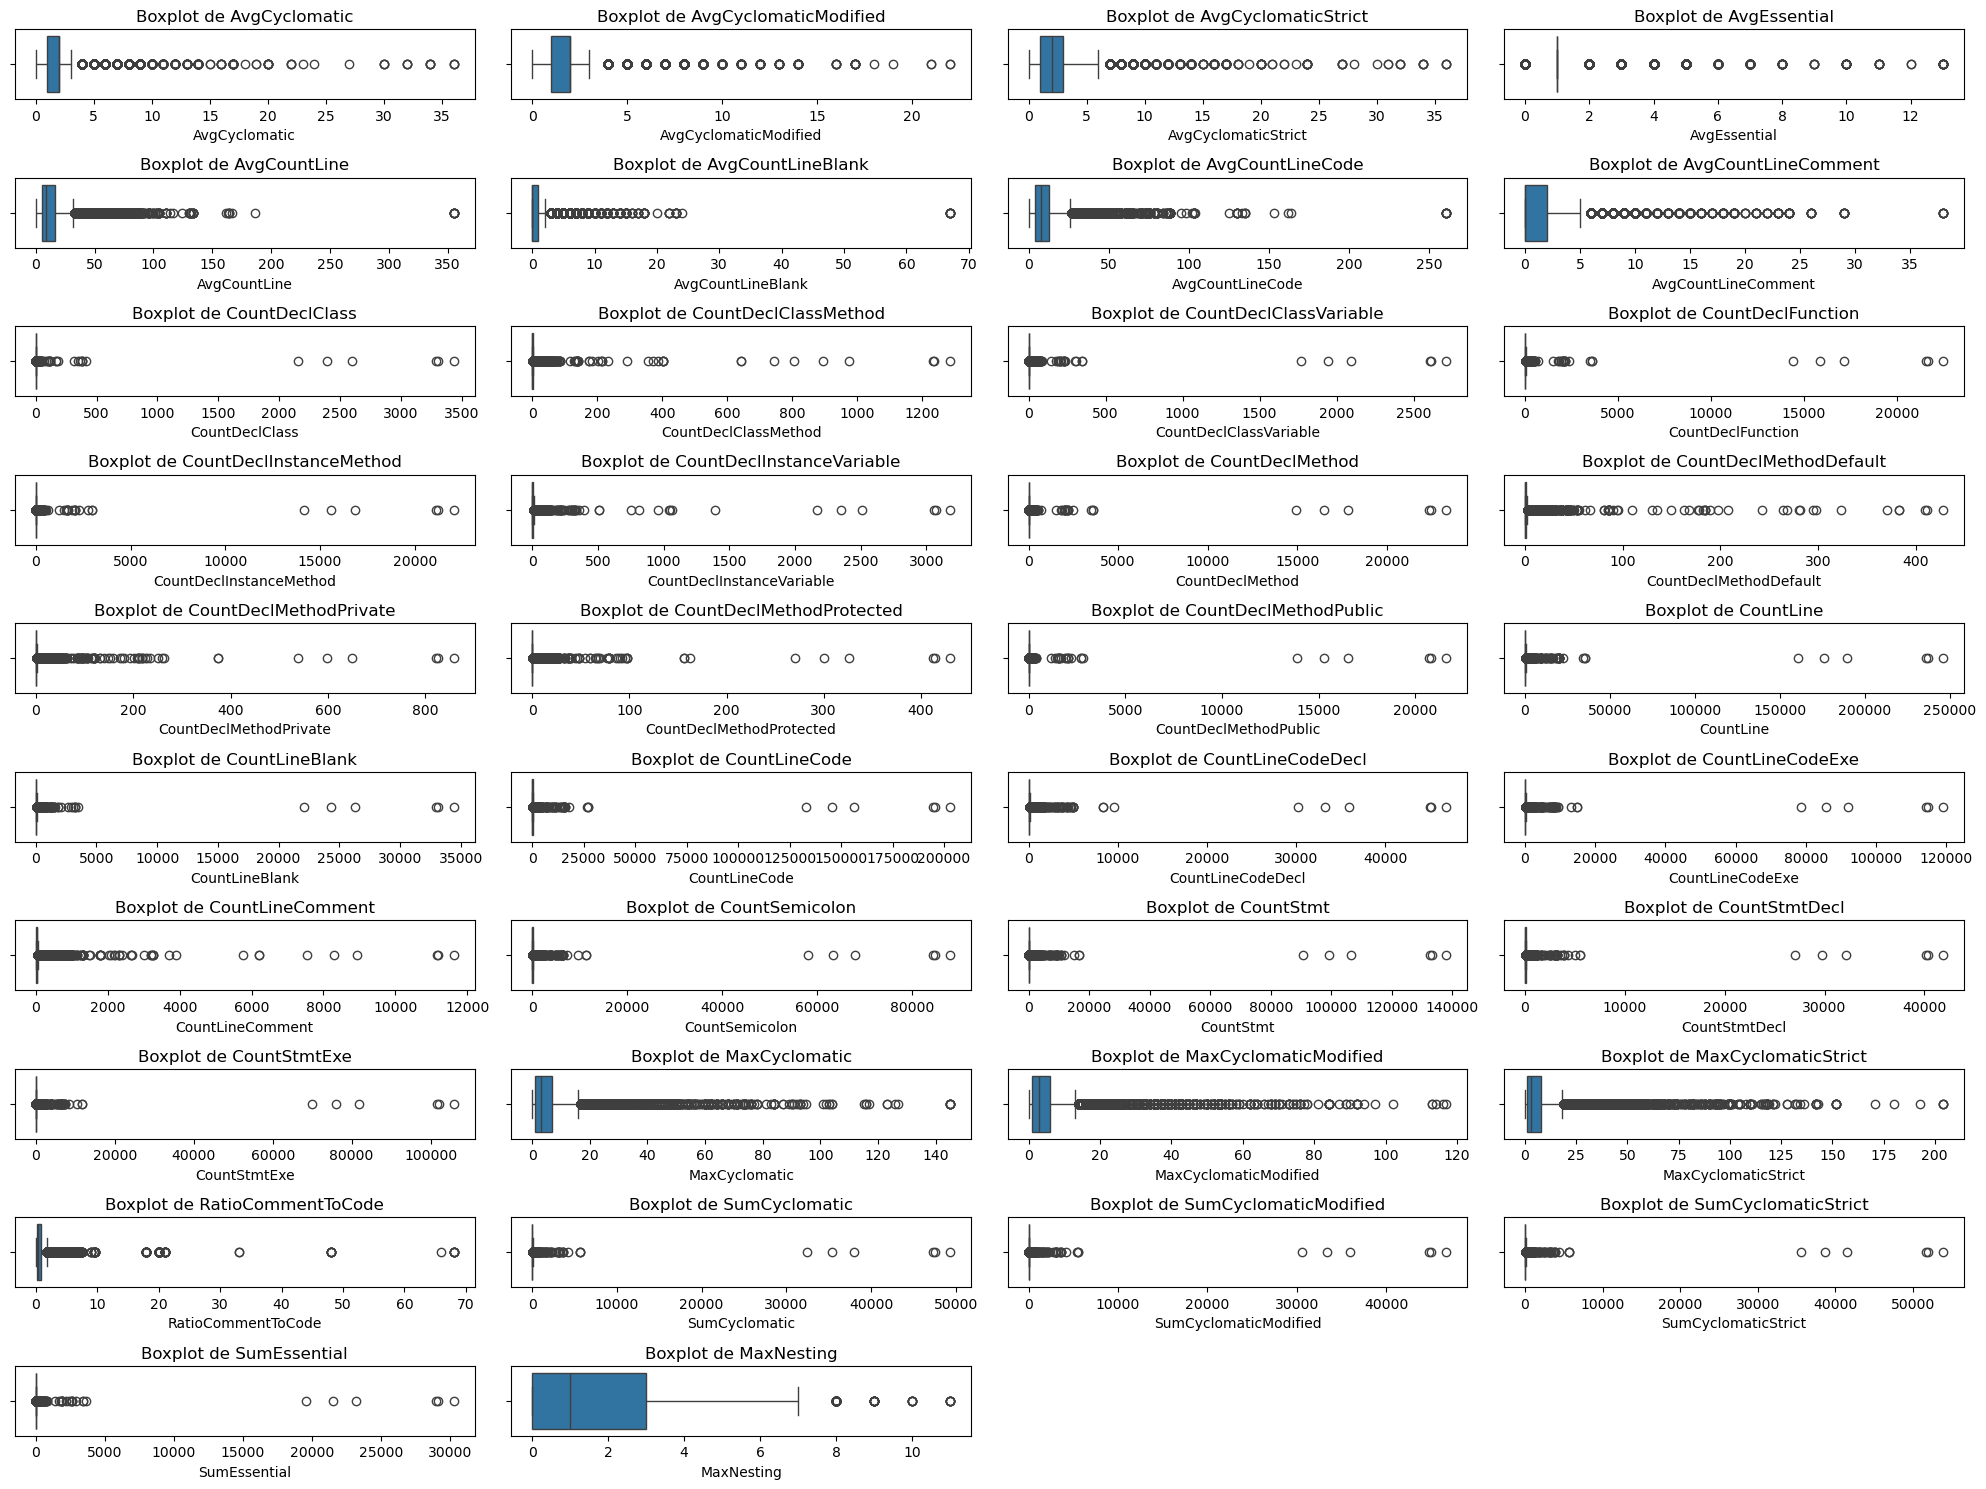

In [3]:
numeric_features = data.select_dtypes(include=['float64']).columns.tolist()
plt.figure(figsize=(20, 15))
for i, feature in enumerate(numeric_features, 1):
    plt.subplot(10, 4, i)
    sns.boxplot(x=data[feature])
    plt.title(f'Boxplot de {feature}')
plt.tight_layout()
plt.show()

On peut voir sur les box plots ci-haut qu'une certaine partie de nos données sont aberrantes. On peut les nettoyer

In [4]:
def remove_outliers(df, numeric_cols, std_threshold=3):
    df_clean = data.copy()
    
    for col in numeric_cols:
        mean = df_clean[col].mean()
        std = df_clean[col].std()
        df_clean = df_clean[abs(df_clean[col] - mean) <= std_threshold * std]
    
    return df_clean

numeric_columns = data.select_dtypes(include=['float64']).columns.tolist()

data_clean = remove_outliers(data, numeric_columns)

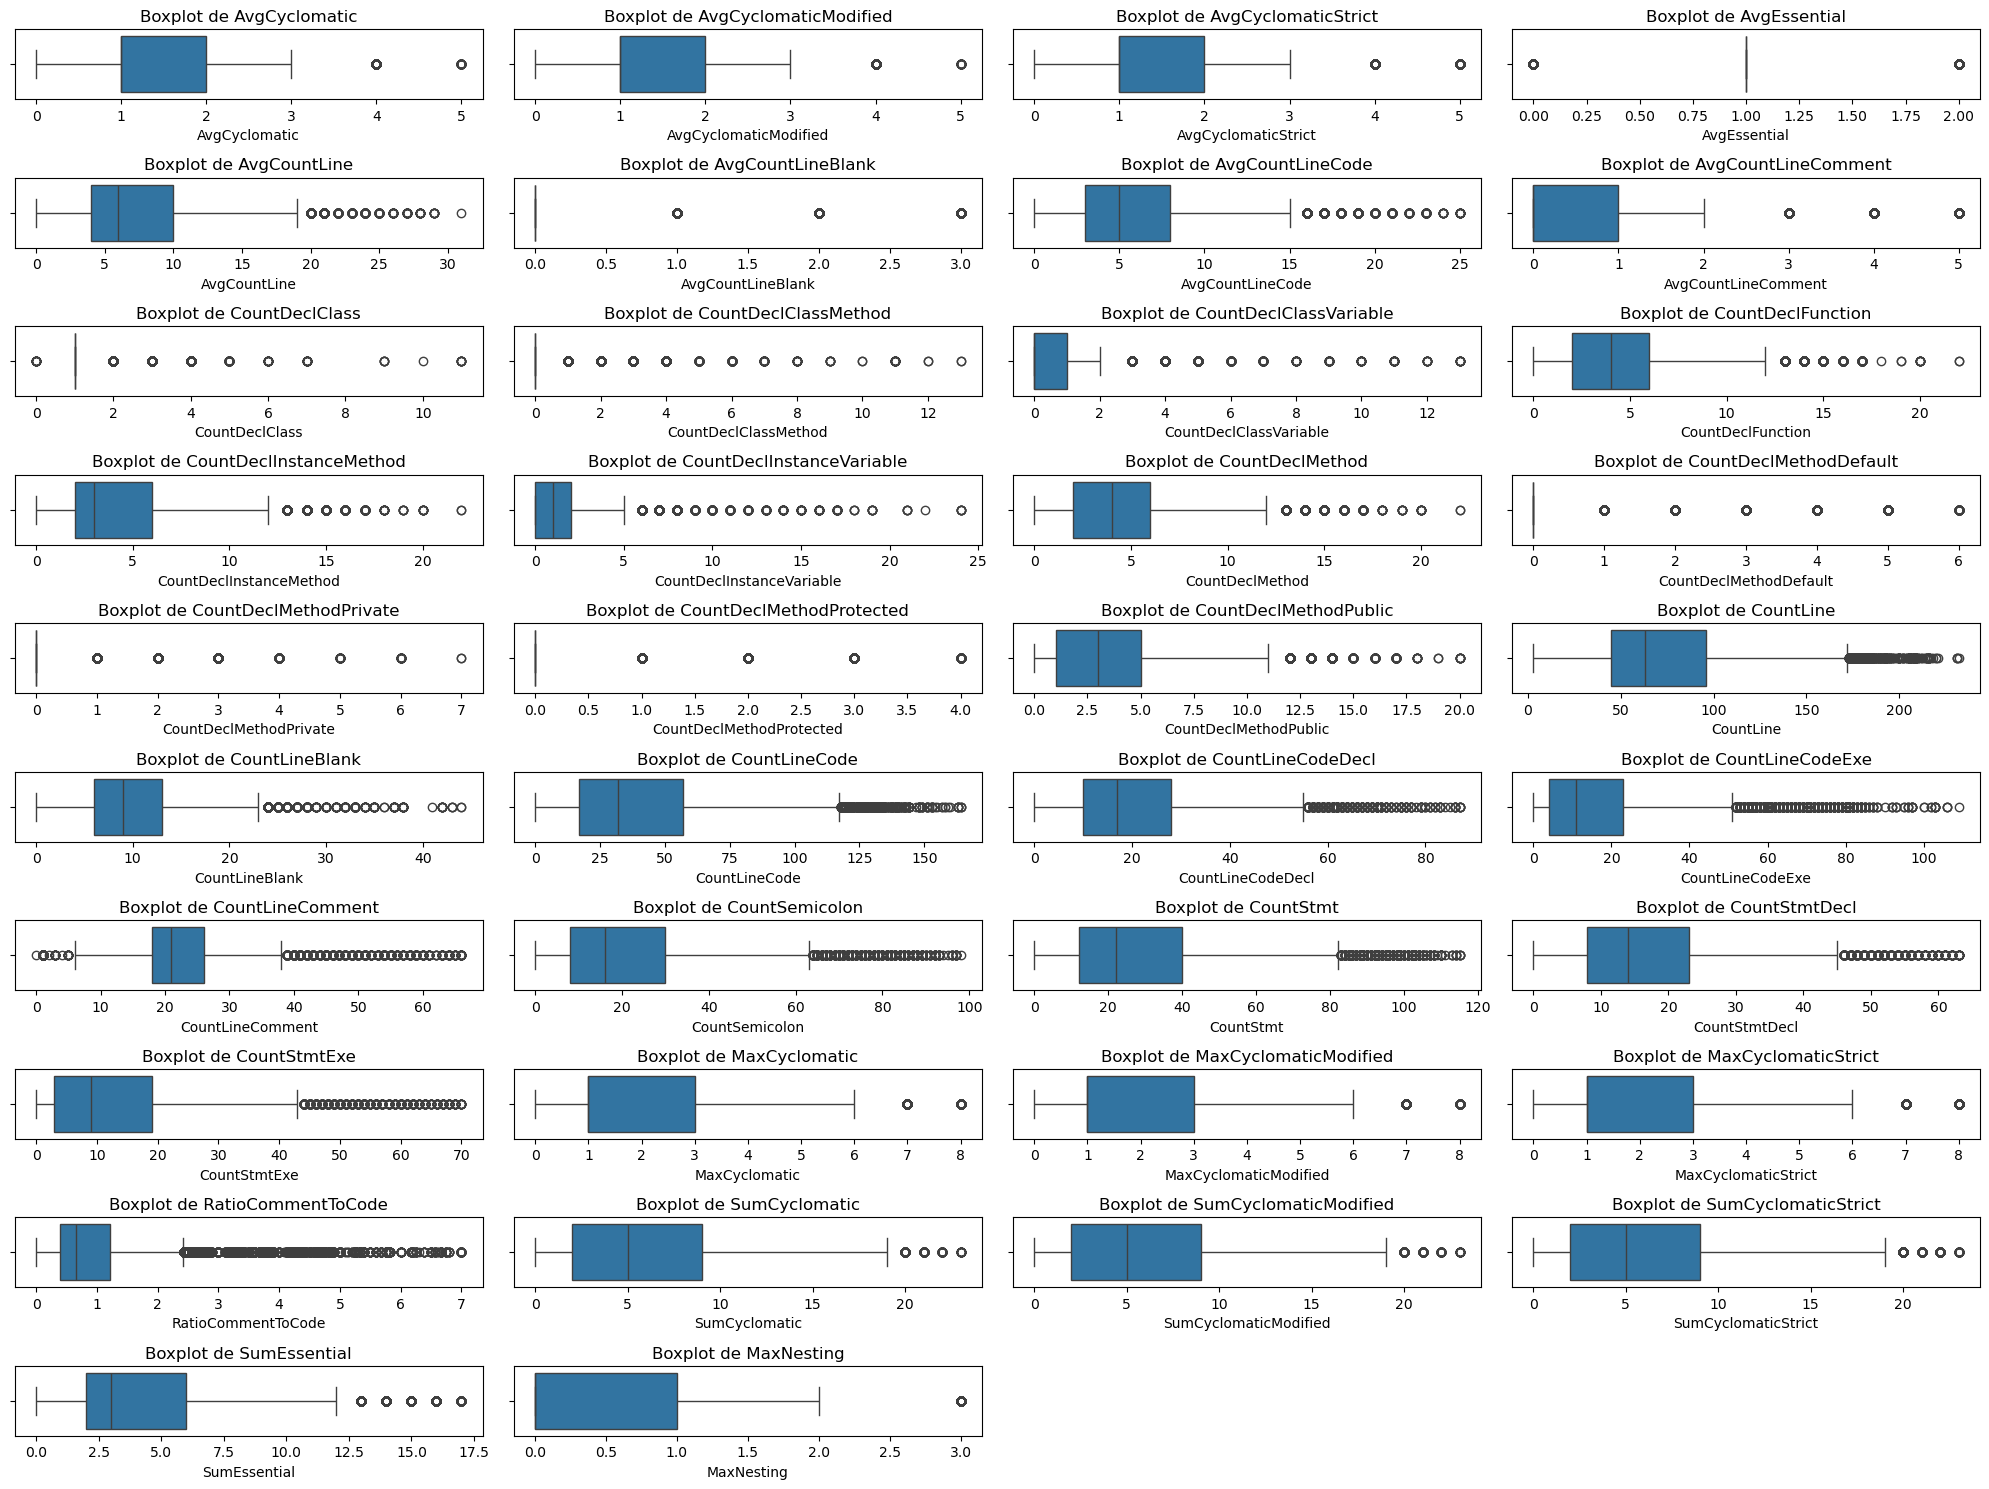

In [5]:
plt.figure(figsize=(20, 15))
for i, feature in enumerate(numeric_features, 1):
    plt.subplot(10, 4, i)
    sns.boxplot(x=data_clean[feature])
    plt.title(f'Boxplot de {feature}')
plt.tight_layout()
plt.show()

In [6]:
x = data_clean.drop('Bug', axis=1)
y = data_clean['Bug']
print(y.value_counts())

Bug
0    18930
1     2973
Name: count, dtype: int64


### 1.2 Feature Engineering

On veut ici créer de nouvelles Features (ex: des ratios ou des interactions entre les features existantes) ou même transformer certaines Features (ex: normalisation ou standardisation des variables pour améliorer la convergence des algorithmes.

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
import pandas as pd

Bug = data_clean.iloc[:, 0]          # Target variable (first column)
features = data_clean.iloc[:, 1:]    # Remaining 38 columns

scaler = StandardScaler()
poly = PolynomialFeatures(degree=2, include_bias=False)

scaled_features = scaler.fit_transform(features)
poly_features = poly.fit_transform(scaled_features)

poly_feature_names = poly.get_feature_names_out(features.columns)

data_transformed = pd.DataFrame(poly_features, columns=poly_feature_names)

data_transformed.insert(0, 'Bug', Bug.values)

print(data_transformed.columns)

Index(['Bug', 'AvgCyclomatic', 'AvgCyclomaticModified', 'AvgCyclomaticStrict',
       'AvgEssential', 'AvgCountLine', 'AvgCountLineBlank', 'AvgCountLineCode',
       'AvgCountLineComment', 'CountDeclClass',
       ...
       'SumCyclomaticModified^2', 'SumCyclomaticModified SumCyclomaticStrict',
       'SumCyclomaticModified SumEssential',
       'SumCyclomaticModified MaxNesting', 'SumCyclomaticStrict^2',
       'SumCyclomaticStrict SumEssential', 'SumCyclomaticStrict MaxNesting',
       'SumEssential^2', 'SumEssential MaxNesting', 'MaxNesting^2'],
      dtype='object', length=780)


In [8]:
x = data_transformed.drop('Bug', axis=1)
y = data_transformed['Bug']
print(y.value_counts())

Bug
0    18930
1     2973
Name: count, dtype: int64


## 2. Partion des Données

In [9]:
x = data_transformed.drop('Bug', axis=1)
y = data_transformed['Bug']
print(y.value_counts())

Bug
0    18930
1     2973
Name: count, dtype: int64


Il y a un déséquilibre, on doit donc remédier à ceci. On utilise SMOTE: 

Distribution des classes avant SMOTE :
Counter({0: 18930, 1: 2973})


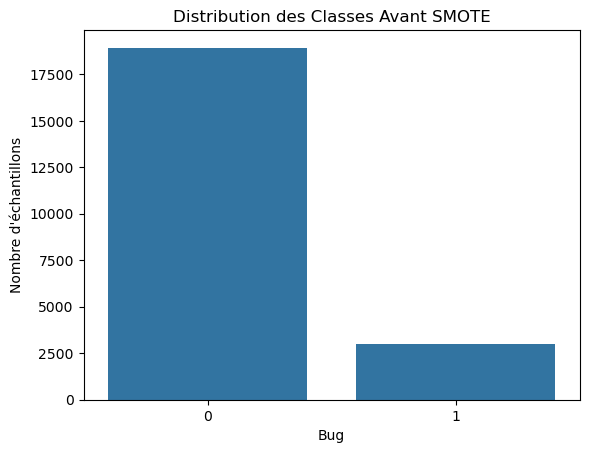

In [10]:
print('Distribution des classes avant SMOTE :')
print(Counter(y))

sns.countplot(x=y)
plt.title('Distribution des Classes Avant SMOTE')
plt.xlabel('Bug')
plt.ylabel('Nombre d\'échantillons')
plt.show()


In [11]:
smote = SMOTE(random_state=42)

x_train_res, y_train_res = smote.fit_resample(x, y)

print('Distribution des classes après SMOTE :')
print(Counter(y_train_res))

Distribution des classes après SMOTE :
Counter({0: 18930, 1: 18930})


On commence par séparer les données d'entraînement (train) des données de vérifications(test). On adopte une partition 80-20

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,         
    random_state=42,        
    stratify=y              
)

## 3. Entraînement

Pour l'entraînement des deux modèles, on utilise *RFECV*, ou Recursive Feature Elimination with Cross-Validation *RFECV* est une méthode d'évaluation et de sélection des caractéristiques dans les modèles d'apprentissage automatique. On l´ utilise ici améliorer les performances de notre modèle, augmenter son interprétabilité et RFECV réduit la complexité du modèle, ce qui diminue les chances de surajustement (*overfitting*)

In [ ]:
variance_threshold = VarianceThreshold(threshold=0.01) 
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42) 

log_reg = LogisticRegression(
    solver='saga',         
    penalty='l1',          
    max_iter=10000,         
    n_jobs=-1,             
    random_state=42       
)

 
rfecv_log_reg = RFECV(
    estimator=log_reg,
    step=0.2,                     # On retire 20% des "features" par itération
    cv=cv,
    scoring='roc_auc',
    verbose=0,              
    n_jobs=-1,
    min_features_to_select=10     # Arbitrairement choisi
)

rfecv_log_reg_pipeline = Pipeline([
    ('variance_threshold', variance_threshold),
    ('scaler', StandardScaler()), # Pour améliorer la performance
    ('rfecv', rfecv_log_reg)
])

rfecv_log_reg_pipeline.fit(x_train_res, y_train_res)

y_pred_log_reg = rfecv_log_reg_pipeline.predict(x_test)
y_pred_proba_log_reg = rfecv_log_reg_pipeline.predict_proba(x_test)[:, 1]

In [36]:
variance_threshold = VarianceThreshold(threshold=0.01) 

random_forest = RandomForestClassifier(
    n_estimators=1500,         
    max_depth=None,            
    min_samples_split=5,     
    min_samples_leaf=5,        
    max_features='sqrt',       
    bootstrap=True,           
    n_jobs=-1,                 
    random_state=42            
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  


rfecv_rf = RFECV(
    estimator=random_forest,
    step=0.2,                       # On retire 20% des "features" par itération
    cv=cv,
    scoring='roc_auc',
    verbose=0,                      
    n_jobs=-1,
    min_features_to_select=10       # Arbitrairement choisi
)

rfecv_rf_pipeline = Pipeline([
    ('variance_threshold', variance_threshold),
    ('scaler', StandardScaler()),   # Pour améliorer la performance
    ('rfecv', rfecv_rf)
])

rfecv_rf_pipeline.fit(x_train_res, y_train_res)

y_pred_rf = rfecv_rf_pipeline.predict(x_test)
y_pred_proba_rf = rfecv_rf_pipeline.predict_proba(x_test)[:, 1]

## Évaluation des Performances

### 1. Matrices de Confusion

In [28]:
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Non-Bug', 'Bug'], 
                yticklabels=['Non-Bug', 'Bug'])
    plt.xlabel('Prédictions')
    plt.ylabel('Vérités Terrain')
    plt.title(title)
    plt.show()

Régression Logistique:

Matrice de confusion - Régression Logistique :
[[2116 1670]
 [ 240  355]]


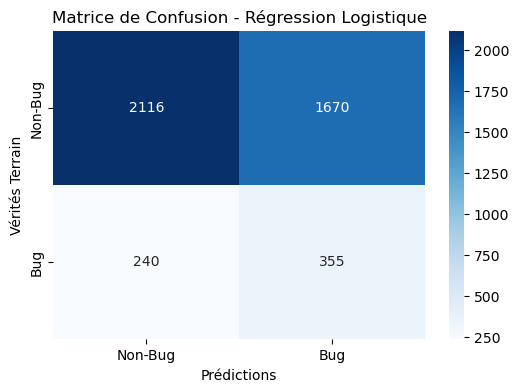

In [29]:
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)
print('Matrice de confusion - Régression Logistique :')
print(conf_matrix_log_reg)
plot_confusion_matrix(conf_matrix_log_reg, 'Matrice de Confusion - Régression Logistique')

Random Forest:

Matrice de confusion - Random Forest :
[[3531  255]
 [ 449  146]]


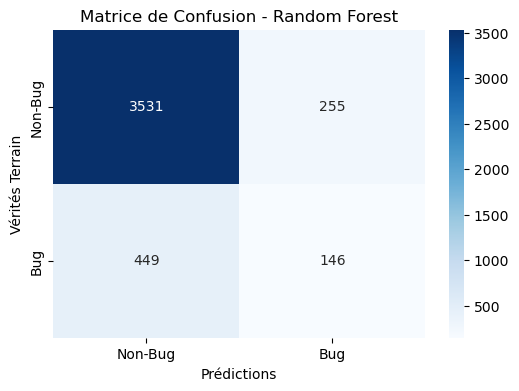

In [30]:
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
print('Matrice de confusion - Random Forest :')
print(conf_matrix_rf)
plot_confusion_matrix(conf_matrix_rf, 'Matrice de Confusion - Random Forest')


### 2. Rapports
On peut produire des rapports pour chacun des entraînements. Pour la régression linéaire:

In [31]:
print(classification_report(y_test, y_pred_log_reg))

              precision    recall  f1-score   support

           0       0.90      0.56      0.69      3786
           1       0.18      0.60      0.27       595

    accuracy                           0.56      4381
   macro avg       0.54      0.58      0.48      4381
weighted avg       0.80      0.56      0.63      4381



Pour random forest:

In [32]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.89      0.93      0.91      3786
           1       0.36      0.25      0.29       595

    accuracy                           0.84      4381
   macro avg       0.63      0.59      0.60      4381
weighted avg       0.82      0.84      0.83      4381



On peut placer ceci ces métriques sur un même 

In [ ]:
from sklearn.metrics import classification_report

report_log_reg = classification_report(y_test, y_pred_log_reg, output_dict=True)
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)

/tmp/ipykernel_326513/2276331343.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Metric', y='Score', hue='Model', data=df_melted, ci=None, palette='muted')


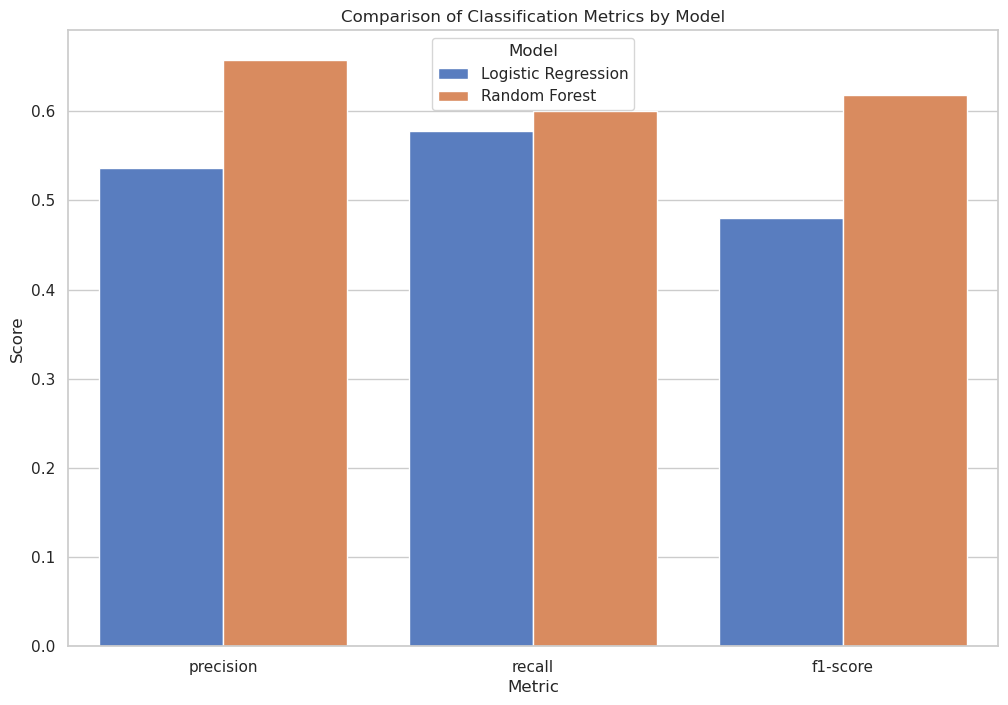

In [40]:
df_log_reg_graph = pd.DataFrame(report_log_reg).transpose()
df_rf_graph = pd.DataFrame(report_rf).transpose()

df_log_reg_graph['Model'] = 'Logistic Regression'
df_rf_graph['Model'] = 'Random Forest'

df_combined = pd.concat([df_log_reg_graph, df_rf_graph], axis=0)

df_combined = df_combined.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')

df_combined = df_combined.reset_index().rename(columns={'index': 'Class'})

df_melted = df_combined.melt(id_vars=['Class', 'Model'], 
                             value_vars=['precision', 'recall', 'f1-score'],
                             var_name='Metric', 
                             value_name='Score')

# Set the aesthetic style of the plots
sns.set(style="whitegrid")

# Initialize the matplotlib figure
plt.figure(figsize=(12, 8))

# Create a barplot
sns.barplot(x='Metric', y='Score', hue='Model', data=df_melted, ci=None, palette='muted')

# Add titles and labels
plt.title('Comparison of Classification Metrics by Model')
plt.ylabel('Score')
plt.xlabel('Metric')

# Show legend
plt.legend(title='Model')

# Display the plot
plt.show()

### 3. Courbes ROC_AUC 
On peut comparer, visuellement les performances, des modèles. Pour la régression linéraire

In [33]:
roc_auc_log_reg = roc_auc_score(y_test, y_pred_proba_log_reg)
print(f'ROC-AUC Score - Régression Logistique : {roc_auc_log_reg:.4f}')
fpr_log, tpr_log, _ = roc_curve(y_test, y_pred_proba_log_reg)

ROC-AUC Score - Régression Logistique : 0.6128


Pour random forest:

In [34]:
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
print(f'ROC-AUC Score - Random Forest : {roc_auc_rf:.4f}')
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)

ROC-AUC Score - Random Forest : 0.7236


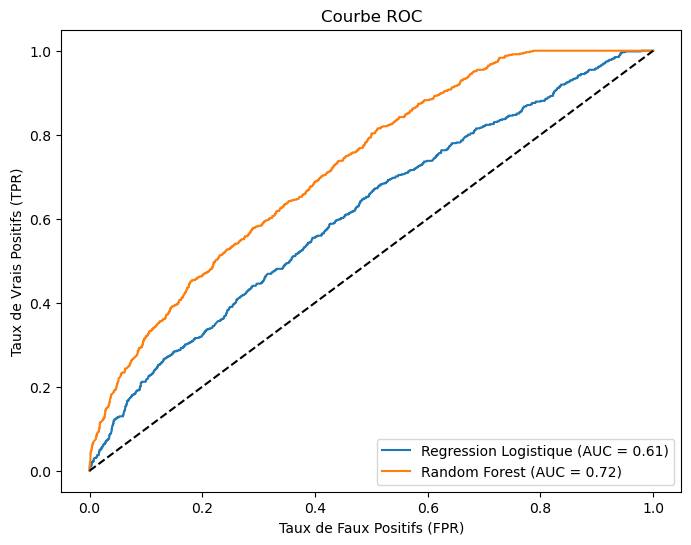

In [35]:
plt.figure(figsize=(8,6))
plt.plot(fpr_log, tpr_log, label=f'Regression Logistique (AUC = {roc_auc_log_reg:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Courbe ROC')
plt.legend(loc='lower right')
plt.show()


## Interprétabilité

Pour la régression logistique:

Selected features (Logistic Regression): ['AvgCyclomaticModified', 'AvgCyclomaticStrict', 'AvgEssential', 'AvgCountLine', 'AvgCountLineBlank', 'AvgCountLineCode', 'AvgCountLineComment', 'CountDeclClass', 'CountDeclClassMethod', 'CountDeclClassVariable', 'CountDeclFunction', 'CountDeclInstanceMethod', 'CountDeclMethod', 'CountDeclMethodDefault', 'CountDeclMethodPrivate', 'CountDeclMethodPublic', 'CountLine', 'CountLineBlank', 'CountLineCodeDecl', 'CountLineCodeExe', 'CountLineComment', 'CountSemicolon', 'CountStmt', 'CountStmtExe', 'MaxCyclomatic', 'MaxCyclomaticModified', 'SumCyclomatic', 'SumCyclomaticModified', 'SumCyclomaticStrict', 'SumEssential', 'AvgCyclomatic^2', 'AvgCyclomatic AvgCyclomaticStrict', 'AvgCyclomatic AvgEssential', 'AvgCyclomatic CountDeclClass', 'AvgCyclomatic CountDeclClassMethod', 'AvgCyclomatic CountDeclClassVariable', 'AvgCyclomatic CountDeclInstanceMethod', 'AvgCyclomatic CountDeclMethod', 'AvgCyclomatic CountDeclMethodPrivate', 'AvgCyclomatic CountLineCodeEx

/tmp/ipykernel_326513/1336121248.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


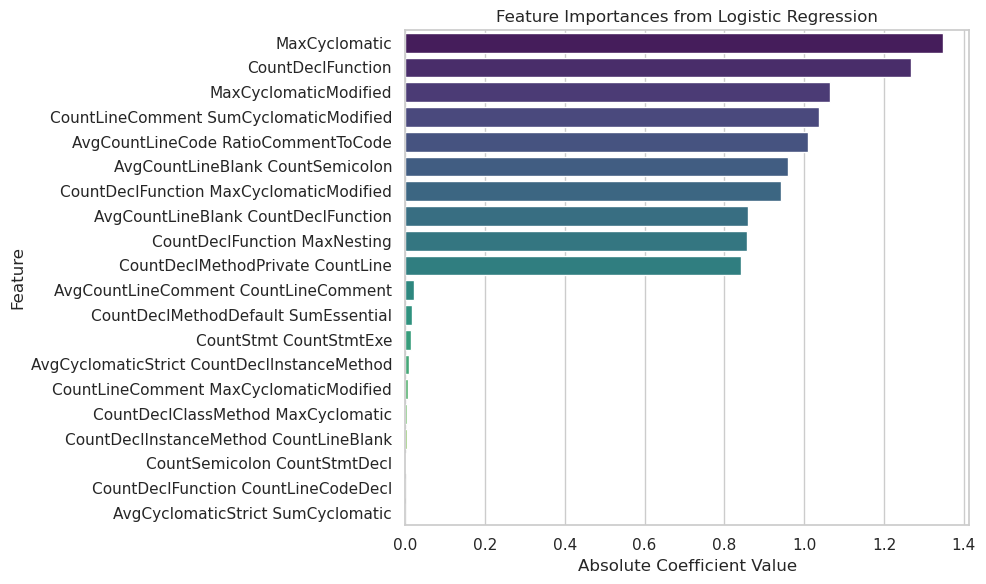

In [85]:
# Access the pipeline steps
variance_threshold_step_log_reg = rfecv_log_reg_pipeline.named_steps['variance_threshold']
rfecv_step_log_reg = rfecv_log_reg_pipeline.named_steps['rfecv']

# Get the support masks
vt_mask_log_reg = variance_threshold_step_log_reg.get_support()
rfecv_mask_log_reg = rfecv_step_log_reg.get_support()

# Apply masks to get selected feature names
features_after_vt_log_reg = x_train_res.columns[vt_mask_log_reg]
selected_features_log_reg = features_after_vt_log_reg[rfecv_mask_log_reg]

# Print the selected features
print("Selected features (Logistic Regression):", selected_features_log_reg.tolist())

# --- Feature Importance Classification ---

# Ensure RFECV has been fitted
if hasattr(rfecv_step_log_reg, 'estimator_'):
    # Extract coefficients
    coefficients = rfecv_step_log_reg.estimator_.coef_[0]  # Assuming binary classification
else:
    raise AttributeError("RFECV estimator is not fitted yet.")

# Create a DataFrame for feature coefficients
feature_coefficients_df = pd.DataFrame({
    'Feature': selected_features_log_reg,
    'Coefficient': coefficients
})

# Calculate absolute values for importance
feature_coefficients_df['Importance'] = feature_coefficients_df['Coefficient'].abs()

# Sort the features by importance
feature_coefficients_df = feature_coefficients_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Display the sorted feature coefficients
print("\nSelected Features Ranked by Importance (Logistic Regression):")
print(feature_coefficients_df[['Feature', 'Coefficient', 'Importance']])

# --- Optional: Visualize Feature Importances ---

# Set plot style
sns.set(style="whitegrid")

# Initialize the matplotlib figure
plt.figure(figsize=(10, 6))

# Combine top 10 and bottom 10 features
plot_data = pd.concat([
    feature_coefficients_df[:10],  # Top 10
    feature_coefficients_df[-10:]  # Bottom 10
])

# Create the plot
sns.barplot(
    x='Importance',
    y='Feature',
    data=plot_data,
    palette='viridis'
)

# Add title and labels
plt.title('Feature Importances from Logistic Regression')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')

# Display the plot
plt.tight_layout()
plt.show()

Pour random forest:

Selected features: ['AvgCountLine', 'AvgCountLineCode', 'AvgCountLineComment', 'CountDeclClassVariable', 'CountDeclInstanceVariable', 'CountLineBlank', 'CountLineCodeDecl', 'CountLineComment', 'CountStmtDecl', 'AvgCyclomatic CountDeclClassVariable', 'AvgCyclomatic CountDeclInstanceVariable', 'AvgCyclomatic CountLineBlank', 'AvgCyclomaticModified CountDeclClassVariable', 'AvgCyclomaticModified CountDeclInstanceVariable', 'AvgCyclomaticModified CountLineBlank', 'AvgCyclomaticStrict CountDeclClassVariable', 'AvgCyclomaticStrict CountDeclInstanceVariable', 'AvgCyclomaticStrict CountLineBlank', 'AvgEssential AvgCountLine', 'AvgEssential AvgCountLineCode', 'AvgEssential CountDeclClassVariable', 'AvgEssential CountDeclInstanceVariable', 'AvgEssential CountLineBlank', 'AvgEssential CountLineCodeDecl', 'AvgEssential CountLineComment', 'AvgCountLine^2', 'AvgCountLine AvgCountLineCode', 'AvgCountLine CountDeclClassVariable', 'AvgCountLine CountDeclMethodDefault', 'AvgCountLine CountLineBlank', 'A

/tmp/ipykernel_326513/3288972191.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


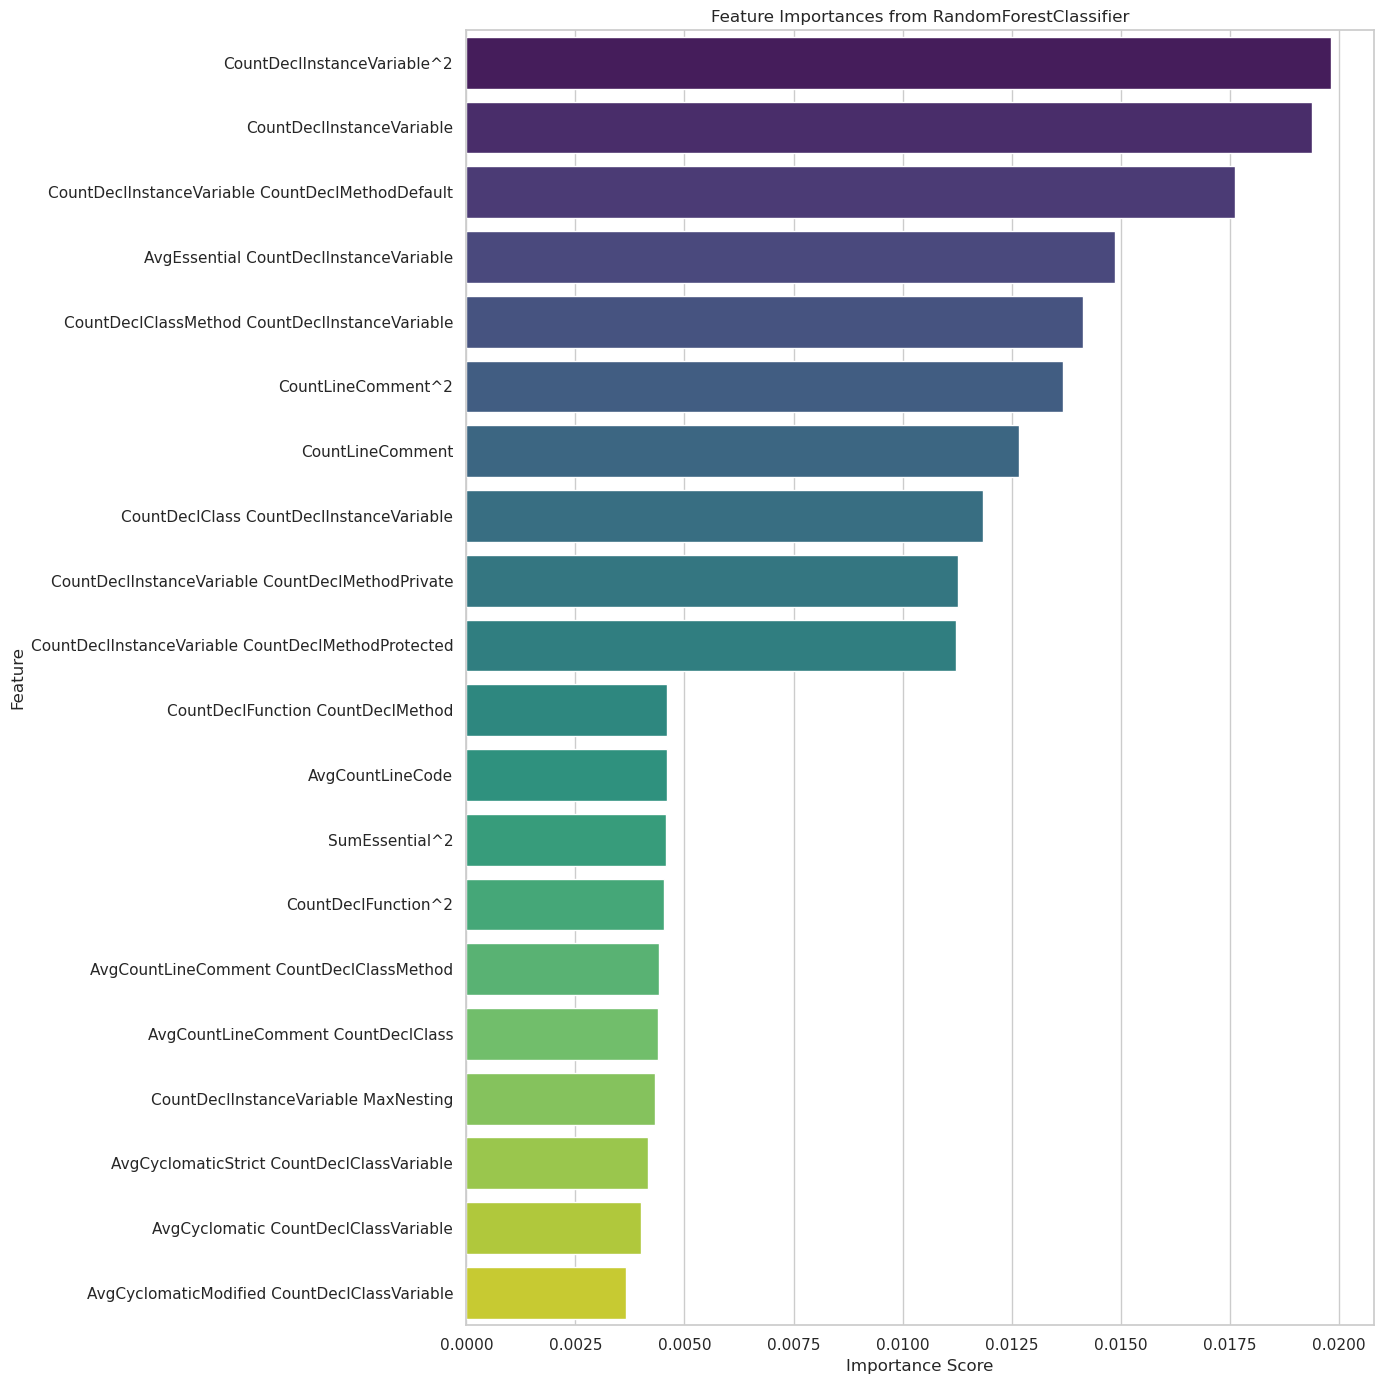

In [86]:
variance_threshold_step = rfecv_rf_pipeline.named_steps['variance_threshold']
rfecv_step = rfecv_rf_pipeline.named_steps['rfecv']
vt_mask = variance_threshold_step.get_support()

rfecv_mask = rfecv_step.get_support()

features_after_vt = x_train_res.columns[vt_mask]

selected_features = features_after_vt[rfecv_mask]

print("Selected features:", selected_features.tolist())

if hasattr(rfecv_step, 'estimator_'):
    feature_importances = rfecv_step.estimator_.feature_importances_
else:
    raise AttributeError("RFECV estimator is not fitted yet.")

# Create a DataFrame for feature importances
feature_importances_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': feature_importances
})

# Sort the features by importance
feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Display the sorted feature importances
print("\nSelected Features Ranked by Importance:")
print(feature_importances_df)

# --- Optional: Visualize Feature Importances ---

# Set plot style
sns.set(style="whitegrid")

# Initialize the matplotlib figure
plt.figure(figsize=(14, 14))

# Combine top 10 and bottom 10 features
plot_data = pd.concat([
    feature_importances_df[:10],  # Top 10
    feature_importances_df[-10:]  # Bottom 10
])

# Create the plot
sns.barplot(
    x='Importance',
    y='Feature',
    data=plot_data,
    palette='viridis'
)

# Add title and labels
plt.title('Feature Importances from RandomForestClassifier')
plt.xlabel('Importance Score')
plt.ylabel('Feature')

# Display the plot
plt.tight_layout()
plt.show()